# VAE — LPC 스프라이트 생성 (PyTorch)

64×64 RGBA 스프라이트 프레임으로 학습하는 합성곱 변분 오토인코더.  
백엔드: PyTorch + MPS (Apple Silicon GPU 자동 감지)

## 1. 환경 설정

In [1]:
import os
import random
import time
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# 노트북 실행 위치와 관계없이 프로젝트 루트를 CWD로 고정
_root = Path(os.path.abspath(''))
for _p in [_root] + list(_root.parents):
    if (_p / 'dataset' / 'processed').exists():
        os.chdir(_p)
        break
print(f'CWD: {Path.cwd()}')

# MPS(Apple Silicon) > CUDA > CPU 순으로 디바이스 선택
if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')

print(f'PyTorch  : {torch.__version__}')
print(f'디바이스 : {DEVICE}')

CWD: /Users/gomuseo/Desktop/Python/vae_test
PyTorch  : 2.12.1
디바이스 : mps


## 2. 설정값

In [2]:
CFG = dict(
    # 데이터
    processed_root = Path('dataset/processed'),
    categories     = ['body'],     # None이면 전체 카테고리 사용
    img_size       = 64,
    channels       = 4,            # RGBA 4채널
    val_ratio      = 0.02,

    # 모델
    latent_dim     = 128,
    base_channels  = 32,           # 첫 번째 Conv 출력 채널 수 (레이어마다 2배)

    # 학습
    epochs         = 50,
    batch_size     = 128,
    lr             = 0.01,
    beta           = 1.0,          # KL 가중치
    num_workers    = 0,            # macOS Jupyter에서 multiprocessing 충돌 방지

    # 기타
    seed           = 42,
    save_dir       = Path('checkpoints_pt'),
    patience       = 20,           # Early Stopping patience (epochs // 10)
)
CFG['patience'] = max(1, CFG['epochs'] // 10)
CFG['save_dir'].mkdir(exist_ok=True)

torch.manual_seed(CFG['seed'])
np.random.seed(CFG['seed'])
random.seed(CFG['seed'])
print('설정 완료.')

설정 완료.


## 3. 데이터셋

In [3]:
class SpriteDataset(Dataset):
    """64×64 RGBA PNG 파일 경로 목록을 받아 텐서로 반환하는 Dataset."""

    def __init__(self, paths: list):
        self.paths     = paths
        self.transform = transforms.ToTensor()  # (H,W,C) uint8 → (C,H,W) float32 [0,1]

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGBA')
        return self.transform(img)  # (4, 64, 64)


def collect_paths(root: Path, categories=None) -> list:
    if categories is None:
        return sorted(str(p) for p in root.rglob('*.png'))
    paths = []
    for cat in categories:
        paths += sorted(str(p) for p in (root / cat).glob('*.png'))
    return paths


all_paths = collect_paths(CFG['processed_root'], CFG['categories'])
if len(all_paths) == 0:
    raise ValueError(f'경로 목록이 비어 있습니다. CWD={Path.cwd()}')
random.shuffle(all_paths)

n_val       = int(len(all_paths) * CFG['val_ratio'])
n_train     = len(all_paths) - n_val
train_paths = all_paths[:n_train]
val_paths   = all_paths[n_train:]

train_ds = SpriteDataset(train_paths)
val_ds   = SpriteDataset(val_paths)

train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'], shuffle=True,
                          num_workers=CFG['num_workers'], drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=CFG['batch_size'], shuffle=False,
                          num_workers=CFG['num_workers'], drop_last=False)  # 검증은 부분 배치 허용

print(f'전체 프레임 : {len(all_paths):,}')
print(f'학습        : {n_train:,}')
print(f'검증        : {n_val:,}')
print(f'배치/에폭   : {len(train_loader):,}')

# 배치 shape 확인
sample_batch = next(iter(train_loader))
print(f'배치 shape  : {sample_batch.shape}  dtype={sample_batch.dtype}')

전체 프레임 : 4,544
학습        : 4,454
검증        : 90
배치/에폭   : 34
배치 shape  : torch.Size([128, 4, 64, 64])  dtype=torch.float32


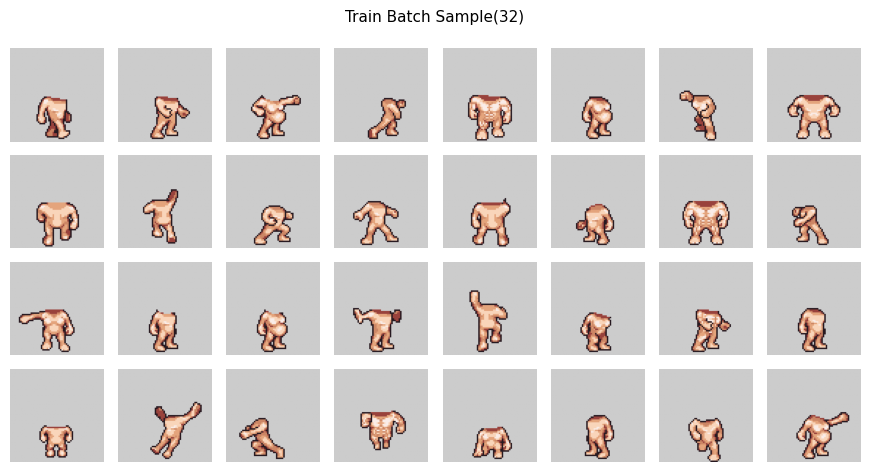

In [4]:
def show_batch(tensor, title='', n=32, bg=(0.8, 0.8, 0.8)):
    """(B, 4, H, W) NCHW 텐서에서 최대 n개 RGBA 프레임을 시각화합니다."""
    n   = min(n, tensor.shape[0])
    nc  = 8
    nr  = (n + nc - 1) // nc
    fig, axes = plt.subplots(nr, nc, figsize=(nc * 1.1, nr * 1.2))
    axes = np.array(axes).flatten()
    imgs = tensor[:n].detach().cpu().permute(0, 2, 3, 1).numpy()  # → (N, H, W, 4)
    for ax, img in zip(axes, imgs):
        alpha = img[:, :, 3:4]
        comp  = img[:, :, :3] * alpha + np.array(bg) * (1 - alpha)
        ax.imshow(np.clip(comp, 0, 1))
        ax.axis('off')
    for ax in axes[n:]:
        ax.axis('off')
    if title:
        plt.suptitle(title, fontsize=11)
    plt.tight_layout()
    plt.show()

show_batch(sample_batch, title='Train Batch Sample(32)')

## 4. 모델 아키텍처

In [18]:
class Encoder(nn.Module):
    """
    4 × Conv2d(stride=2) → Flatten → Linear(μ) + Linear(log σ²)
    공간 크기: 64 → 32 → 16 → 8 → 4
    입력 포맷: (B, C, H, W)  — PyTorch NCHW
    """
    def __init__(self, channels=4, base_ch=32, latent_dim=256):
        super().__init__()
        layers = []
        in_ch  = channels
        ch     = base_ch
        for _ in range(4):
            layers += [
                nn.Conv2d(in_ch, ch, 4, stride=2, padding=1),
                nn.BatchNorm2d(ch),
                nn.LeakyReLU(0.2),
            ]
            in_ch = ch
            ch   *= 2
        self.conv     = nn.Sequential(*layers)
        self.flat_dim = (base_ch * 8) * 4 * 4   # 256 × 4 × 4 = 4096
        self.fc_mu    = nn.Linear(self.flat_dim, latent_dim)
        self.fc_lv    = nn.Linear(self.flat_dim, latent_dim)

    def forward(self, x):
        h  = self.conv(x).flatten(1)
        return self.fc_mu(h), self.fc_lv(h)


class Decoder(nn.Module):
    """
    Linear → Reshape → 4 × ConvTranspose2d(stride=2) → Sigmoid
    공간 크기: 4 → 8 → 16 → 32 → 64
    """
    def __init__(self, channels=4, base_ch=32, latent_dim=256):
        super().__init__()
        self.start_ch = base_ch * 8   # 256
        self.fc       = nn.Linear(latent_dim, self.start_ch * 4 * 4)
        layers        = []
        in_ch         = self.start_ch
        out_chs       = [base_ch * 4, base_ch * 2, base_ch, channels]
        for i, out_ch in enumerate(out_chs):
            layers.append(nn.ConvTranspose2d(in_ch, out_ch, 4, stride=2, padding=1))
            if i < len(out_chs) - 1:
                layers += [nn.BatchNorm2d(out_ch), nn.ReLU()]
            else:
                layers.append(nn.Sigmoid())  # 최종 출력 → [0, 1]
            in_ch = out_ch
        self.deconv = nn.Sequential(*layers)

    def forward(self, z):
        h = self.fc(z).view(-1, self.start_ch, 4, 4)
        return self.deconv(h)


class VAE(nn.Module):
    """인코더 + 재매개변수화 + 디코더로 구성된 VAE 모델."""

    def __init__(self, channels=4, base_ch=32, latent_dim=256):
        super().__init__()
        self.latent_dim = latent_dim
        self.encoder    = Encoder(channels, base_ch, latent_dim)
        self.decoder    = Decoder(channels, base_ch, latent_dim)

    def reparameterize(self, mu, log_var):
        """재매개변수화 기법: z = μ + ε·σ  (ε ~ N(0,I))"""
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, log_var = self.encoder(x)
        z           = self.reparameterize(mu, log_var)
        return self.decoder(z), mu, log_var

    @torch.no_grad()
    def sample(self, n, device):
        """사전 분포 N(0,I)에서 n개 이미지 생성"""
        z = torch.randn(n, self.latent_dim, device=device)
        return self.decoder(z)


model = VAE(
    channels   = CFG['channels'],
    base_ch    = CFG['base_channels'],
    latent_dim = CFG['latent_dim'],
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
enc_params   = sum(p.numel() for p in model.encoder.parameters())
dec_params   = sum(p.numel() for p in model.decoder.parameters())
print(f'인코더 파라미터 : {enc_params:,}')
print(f'디코더 파라미터 : {dec_params:,}')
print(f'전체 파라미터   : {total_params:,}')

인코더 파라미터 : 1,740,448
디코더 파라미터 : 1,219,236
전체 파라미터   : 2,959,684


In [19]:
# 순전파 shape 확인
dummy = torch.zeros(4, CFG['channels'], CFG['img_size'], CFG['img_size']).to(DEVICE)
recon, mu, log_var = model(dummy)
print(f'입력      : {dummy.shape}')
print(f'복원 출력 : {recon.shape}  범위=[{recon.min():.3f}, {recon.max():.3f}]')
print(f'μ         : {mu.shape}')
print(f'log_var   : {log_var.shape}')

입력      : torch.Size([4, 4, 64, 64])
복원 출력 : torch.Size([4, 4, 64, 64])  범위=[0.078, 0.955]
μ         : torch.Size([4, 128])
log_var   : torch.Size([4, 128])


## 5. 손실 함수

In [20]:
def vae_loss(recon, x, mu, log_var, beta=1.0):
    """MSE 복원 손실 + β·KL 발산 (배치 평균으로 정규화)"""
    batch = x.size(0)
    recon_loss = F.mse_loss(recon, x, reduction='sum') / batch
    kl_loss    = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp()) / batch
    return recon_loss + beta * kl_loss, recon_loss, kl_loss


# 단위 테스트
x_t = torch.rand(8, CFG['channels'], 64, 64).to(DEVICE)
r_t, m_t, lv_t = model(x_t)
total, rl, kl = vae_loss(r_t, x_t, m_t, lv_t, CFG['beta'])
print(f'총 손실   : {total.item():.6f}')
print(f'복원 손실 : {rl.item():.6f}')
print(f'KL 발산   : {kl.item():.6f}')

총 손실   : 1680.924072
복원 손실 : 1664.937500
KL 발산   : 15.986611


## 6. 학습

In [21]:
optimizer  = torch.optim.Adam(model.parameters(), lr=CFG['lr'])
# Cosine Annealing — TF 버전과 동일한 스케줄
scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CFG['epochs'], eta_min=1e-5
)

patience   = CFG['patience']
print(f'Early Stopping patience: {patience} 에폭')

history = {'loss': [], 'recon_loss': [], 'kl_loss': [],
           'val_loss': [], 'val_recon_loss': [], 'val_kl_loss': []}

best_val_loss = float('inf')
no_improve    = 0
best_ckpt     = CFG['save_dir'] / 'best.pt'

t_start = time.time()

for epoch in range(1, CFG['epochs'] + 1):
    # ── 학습 ──
    model.train()
    t_loss = r_loss = k_loss = 0.0
    for x in train_loader:
        x = x.to(DEVICE)
        optimizer.zero_grad()
        recon, mu, log_var = model(x)
        loss, rl, kl = vae_loss(recon, x, mu, log_var, CFG['beta'])
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # 그래디언트 클리핑
        optimizer.step()
        t_loss += loss.item(); r_loss += rl.item(); k_loss += kl.item()

    n = len(train_loader)
    history['loss'].append(t_loss / n)
    history['recon_loss'].append(r_loss / n)
    history['kl_loss'].append(k_loss / n)

    # ── 검증 ──
    model.eval()
    vt_loss = vr_loss = vk_loss = 0.0
    with torch.no_grad():
        for x in val_loader:
            x = x.to(DEVICE)
            recon, mu, log_var = model(x)
            loss, rl, kl = vae_loss(recon, x, mu, log_var, CFG['beta'])
            vt_loss += loss.item(); vr_loss += rl.item(); vk_loss += kl.item()

    vn = max(len(val_loader), 1)  # 빈 val_loader 방지
    val_loss = vt_loss / vn
    history['val_loss'].append(val_loss)
    history['val_recon_loss'].append(vr_loss / vn)
    history['val_kl_loss'].append(vk_loss / vn)

    scheduler.step()

    # ── 체크포인트 & Early Stopping ──
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        no_improve    = 0
        torch.save(model.state_dict(), best_ckpt)
        improved = '  ✓ best'
    else:
        no_improve += 1
        improved = ''

    print(f'Epoch {epoch:3d}/{CFG["epochs"]}  '
          f'loss={history["loss"][-1]:.4f}  '
          f'val_loss={val_loss:.4f}  '
          f'lr={scheduler.get_last_lr()[0]:.2e}{improved}')

    if no_improve >= patience:
        print(f'\nEarly Stopping — {patience} 에폭 동안 개선 없음.')
        break

elapsed = time.time() - t_start
print(f'\n학습 완료 — 소요 시간: {elapsed/60:.1f}분  실제 에폭: {epoch}/{CFG["epochs"]}')

Early Stopping patience: 5 에폭
Epoch   1/50  loss=5815.6573  val_loss=777.0383  lr=9.99e-03  ✓ best
Epoch   2/50  loss=503.9578  val_loss=487.5492  lr=9.96e-03  ✓ best
Epoch   3/50  loss=311.0679  val_loss=292.8457  lr=9.91e-03  ✓ best
Epoch   4/50  loss=265.6117  val_loss=264.8734  lr=9.84e-03  ✓ best
Epoch   5/50  loss=239.1115  val_loss=241.1567  lr=9.76e-03  ✓ best
Epoch   6/50  loss=217.5774  val_loss=215.3842  lr=9.65e-03  ✓ best
Epoch   7/50  loss=197.2784  val_loss=194.5356  lr=9.52e-03  ✓ best
Epoch   8/50  loss=180.7298  val_loss=180.6700  lr=9.38e-03  ✓ best
Epoch   9/50  loss=165.6396  val_loss=163.0863  lr=9.22e-03  ✓ best
Epoch  10/50  loss=153.9038  val_loss=151.3625  lr=9.05e-03  ✓ best
Epoch  11/50  loss=144.6712  val_loss=146.0376  lr=8.85e-03  ✓ best
Epoch  12/50  loss=138.0025  val_loss=137.0227  lr=8.65e-03  ✓ best
Epoch  13/50  loss=130.3517  val_loss=132.4779  lr=8.42e-03  ✓ best
Epoch  14/50  loss=124.5230  val_loss=126.4255  lr=8.19e-03  ✓ best
Epoch  15/50  los

## 7. 학습 곡선

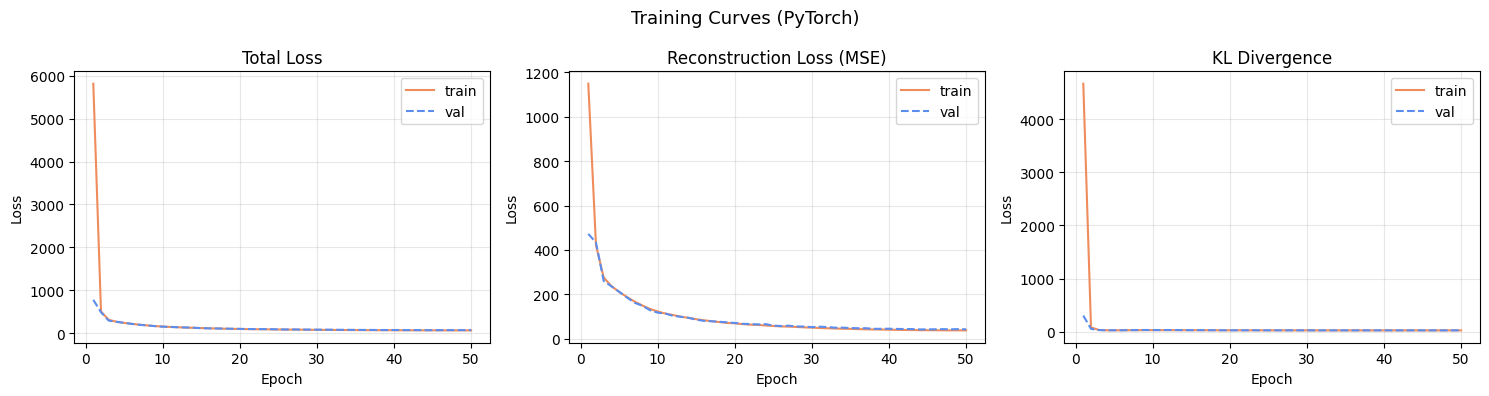

In [27]:
epochs_x = range(1, len(history['loss']) + 1)
keys     = ['loss', 'recon_loss', 'kl_loss']
titles   = ['Total Loss', 'Reconstruction Loss (MSE)', 'KL Divergence']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, key, title in zip(axes, keys, titles):
    ax.plot(epochs_x, history[key],           label='train', color='#ee8c5b')
    ax.plot(epochs_x, history[f'val_{key}'],  label='val',   color='#5b8dee', linestyle='--')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Training Curves (PyTorch)', fontsize=13)
plt.tight_layout()
plt.show()

## 8. 복원 결과

최적 가중치 로드 완료.


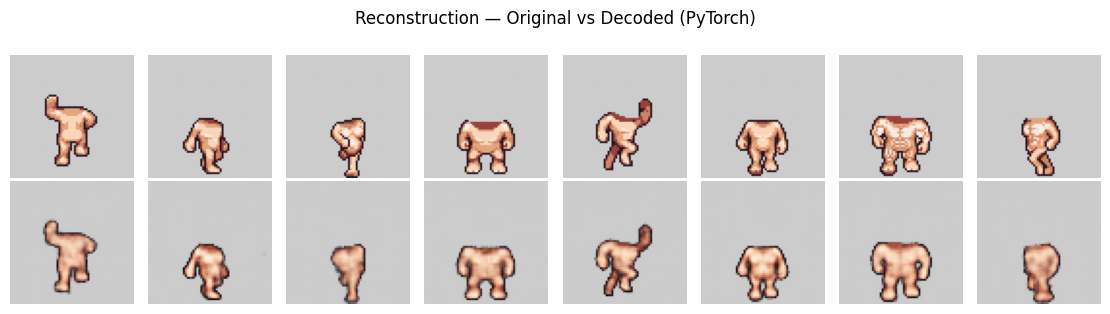

In [28]:
# 최적 가중치 로드
best_ckpt = CFG['save_dir'] / 'best.pt'
if best_ckpt.exists():
    model.load_state_dict(torch.load(best_ckpt, map_location=DEVICE))
    print('최적 가중치 로드 완료.')
else:
    print('체크포인트 없음 — 현재 가중치 사용.')

def to_rgb_list(tensor, bg=(0.8, 0.8, 0.8)):
    """(N, 4, H, W) NCHW → 배경 합성 RGB 배열 리스트"""
    imgs = tensor.detach().cpu().permute(0, 2, 3, 1).numpy()  # (N, H, W, 4)
    out  = []
    for img in imgs:
        comp = img[:, :, :3] * img[:, :, 3:4] + np.array(bg) * (1 - img[:, :, 3:4])
        out.append(np.clip(comp, 0, 1))
    return out

model.eval()
src_batch = next(iter(val_loader)).to(DEVICE)
n_show    = min(8, src_batch.shape[0])
src_batch = src_batch[:n_show]

with torch.no_grad():
    recon_batch, _, _ = model(src_batch)

origs  = to_rgb_list(src_batch)
recons = to_rgb_list(recon_batch)

fig, axes = plt.subplots(2, n_show, figsize=(n_show * 1.4, 3.2))
axes = np.array(axes).reshape(2, n_show)
for i in range(n_show):
    axes[0, i].imshow(origs[i]);  axes[0, i].axis('off')
    axes[1, i].imshow(recons[i]); axes[1, i].axis('off')
axes[0, 0].set_ylabel('Original',      fontsize=9)
axes[1, 0].set_ylabel('Reconstructed', fontsize=9)

plt.suptitle('Reconstruction — Original vs Decoded (PyTorch)', fontsize=12)
plt.tight_layout()
plt.show()

## 9. 생성 — 사전 분포에서 샘플링

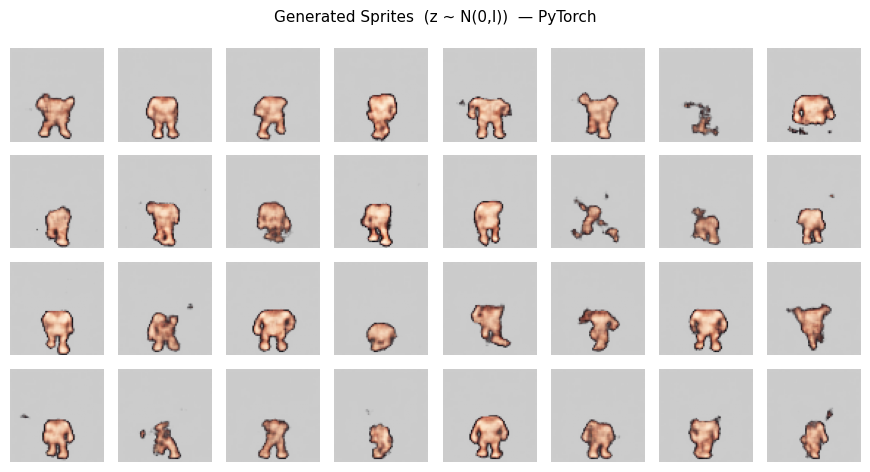

In [29]:
model.eval()
generated = model.sample(32, DEVICE)
show_batch(generated, title='Generated Sprites  (z ~ N(0,I))  — PyTorch', n=32)

## 10. 잠재 공간 보간

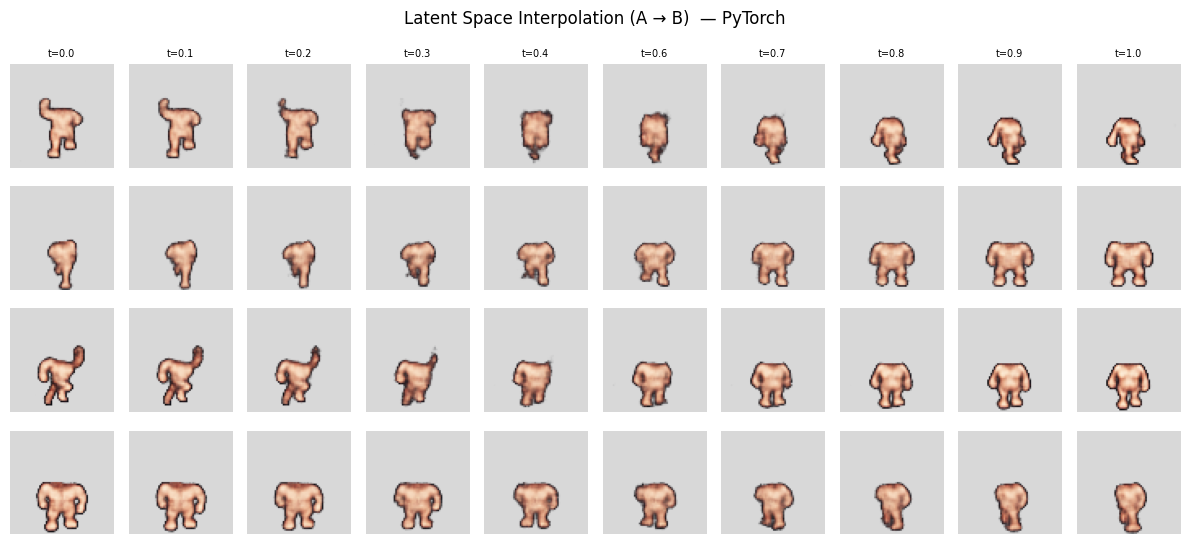

In [30]:
@torch.no_grad()
def interpolate(vae, img_a, img_b, steps=10):
    """잠재 공간에서 두 이미지 사이를 선형 보간합니다."""
    mu_a, _ = vae.encoder(img_a.unsqueeze(0))
    mu_b, _ = vae.encoder(img_b.unsqueeze(0))
    ts      = torch.linspace(0, 1, steps, device=img_a.device)
    zs      = [(1 - t) * mu_a + t * mu_b for t in ts]
    return torch.cat([vae.decoder(z) for z in zs], dim=0)


n_pairs  = 4
steps    = 10
src_imgs = next(iter(val_loader)).to(DEVICE)
n_pairs  = min(n_pairs, src_imgs.shape[0] // 2)

bg = (0.85, 0.85, 0.85)
fig, axes = plt.subplots(n_pairs, steps, figsize=(steps * 1.2, n_pairs * 1.4))
axes = np.array(axes).reshape(n_pairs, steps)

model.eval()
for row in range(n_pairs):
    interp = interpolate(model, src_imgs[row * 2], src_imgs[row * 2 + 1], steps)
    for col, frame in enumerate(to_rgb_list(interp, bg=bg)):
        axes[row, col].imshow(frame)
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(f't={col/(steps-1):.1f}', fontsize=7)

plt.suptitle('Latent Space Interpolation (A → B)  — PyTorch', fontsize=12)
plt.tight_layout()
plt.show()

## 11. 저장 및 불러오기

In [26]:
import json as _json

save_dir = CFG['save_dir']

# 1) 최종 가중치 저장
torch.save(model.state_dict(), save_dir / 'final.pt')
print(f'가중치 저장 → {save_dir / "final.pt"}')

# 2) 설정값 저장
_exclude = {'num_workers'}
cfg_out  = {k: str(v) if isinstance(v, Path) else v
            for k, v in CFG.items() if k not in _exclude}
with open(save_dir / 'config.json', 'w') as _f:
    _json.dump(cfg_out, _f, indent=2)
print(f'설정값 저장 → {save_dir / "config.json"}')
print('모든 저장 완료.')

print("""
=== Streamlit 불러오기 예시 ===
import json, torch
from pathlib import Path

with open('checkpoints_pt/config.json') as f:
    cfg = json.load(f)

model = VAE(cfg['channels'], cfg['base_channels'], cfg['latent_dim'])
model.load_state_dict(torch.load('checkpoints_pt/best.pt', map_location='cpu'))
model.eval()

imgs = model.sample(16, torch.device('cpu'))  # (16, 4, 64, 64)
""")

가중치 저장 → checkpoints_pt/final.pt
설정값 저장 → checkpoints_pt/config.json
모든 저장 완료.

=== Streamlit 불러오기 예시 ===
import json, torch
from pathlib import Path

with open('checkpoints_pt/config.json') as f:
    cfg = json.load(f)

model = VAE(cfg['channels'], cfg['base_channels'], cfg['latent_dim'])
model.load_state_dict(torch.load('checkpoints_pt/best.pt', map_location='cpu'))
model.eval()

imgs = model.sample(16, torch.device('cpu'))  # (16, 4, 64, 64)

